In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

df = pd.read_csv("indian_dataset_clean.csv")
df.head()

,text,clean_text,label,source,topic
0,"IG history, bro just go to live leak you shou...",ig history bro just go to live leak you shoul...,negative,reddit_india,general
1,Bhakts having a meltdown.,bhakts having a meltdown,negative,reddit_india,general
2,Nothing happens on time. Road rules aren't fol...,nothing happens on time road rules arent follo...,neutral,reddit_india,general
3,What's the subreddit name?,whats the subreddit name,neutral,reddit_india,general
4,"Well, I am young at heart 😆",well i am young at heart,positive,reddit_india,general


In [2]:
#Advanced Cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    
    # remove useless words
    if text.strip() in ["removed", "deleted"]:
        return ""
    
    return text

df["clean_text"] = df["text"].apply(clean_text)

# remove empty rows
df = df[df["clean_text"] != ""]
df = df[df["clean_text"].str.len() > 10]

In [3]:
#Creating Real Topic
topic_dict = {
    "Politics": ["government", "election", "minister", "policy", "modi", "bjp", "congress"],
    "Sports": ["cricket", "match", "ipl", "team", "win", "player"],
    "Economy": ["price", "petrol", "job", "market", "inflation", "economy"],
    "Technology": ["ai", "tech", "software", "data", "app", "phone", "internet"],
    "Education": ["exam", "college", "student", "study", "school"],
    "Social Issues": ["women", "crime", "law", "police", "rights"],
    "Entertainment": ["movie", "film", "actor", "music", "show"],
    "General": ["india", "country", "indian"]
}

In [4]:
def assign_topic(text):
    for topic, keywords in topic_dict.items():
        for word in keywords:
            if word in text:
                return topic
    return "Other"

df["topic"] = df["clean_text"].apply(assign_topic)

In [5]:
topic_counts = df["topic"].value_counts()
print(topic_counts)

topic
Other            25575
Technology       13322
Politics          5057
General           3972
Sports            2356
Economy           2012
Social Issues     1345
Education          856
Entertainment      644
Name: count, dtype: int64


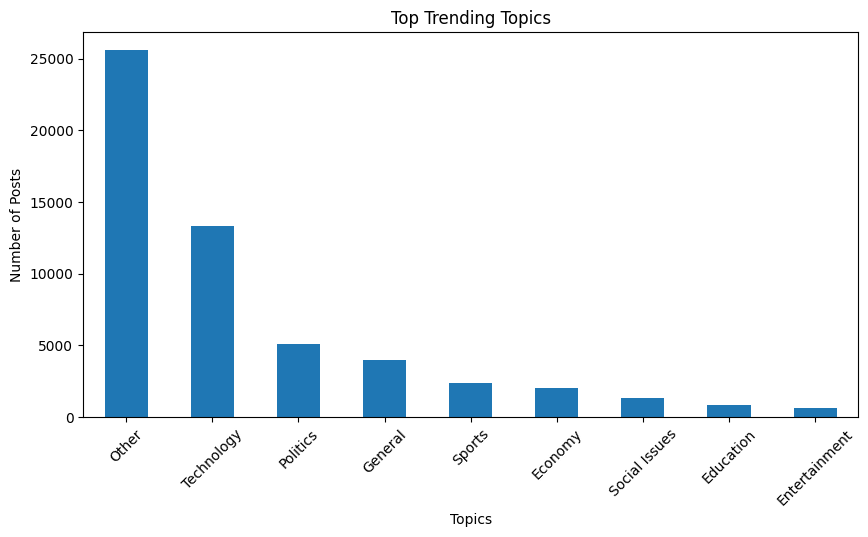

In [6]:
plt.figure(figsize=(10,5))
topic_counts.plot(kind="bar")
plt.title("Top Trending Topics")
plt.xlabel("Topics")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.show()

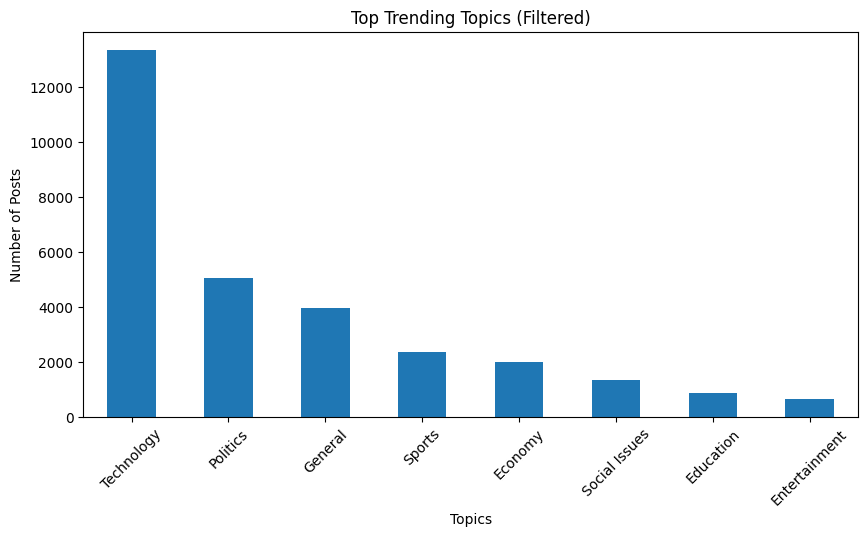

In [7]:
# Get topic counts
topic_counts = df["topic"].value_counts()

# Remove 'Other'
topic_counts_clean = topic_counts.drop("Other")

# Plot
plt.figure(figsize=(10,5))
topic_counts_clean.plot(kind="bar")

plt.title("Top Trending Topics (Filtered)")
plt.xlabel("Topics")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)

plt.show()

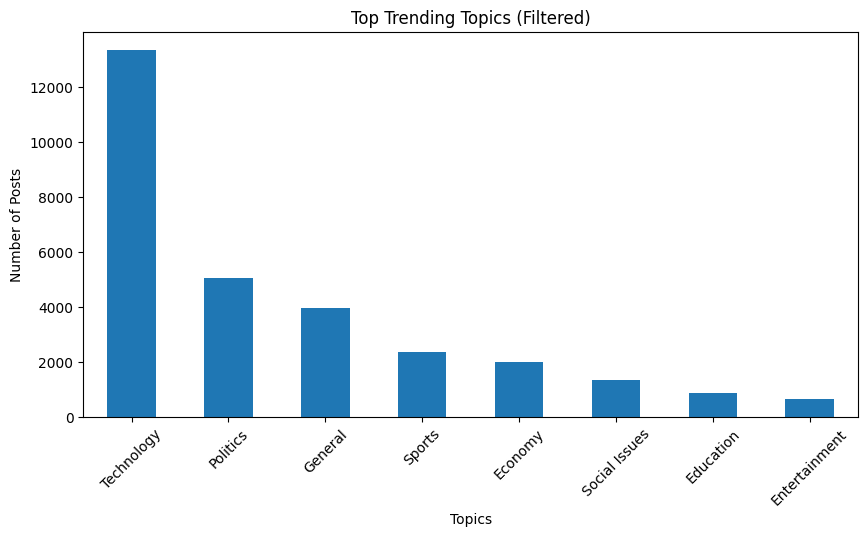

In [8]:
# Get topic counts
topic_counts = df["topic"].value_counts()

# Remove 'Other'
topic_counts_clean = topic_counts.drop("Other")

# Plot
plt.figure(figsize=(10,5))
topic_counts_clean.plot(kind="bar")

plt.title("Top Trending Topics (Filtered)")
plt.xlabel("Topics")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)

plt.show()

In [9]:
#checking topic and table
print(df["topic"])
print(df["label"])

0             Other
1             Other
2        Technology
3             Other
4             Other
            ...    
59994    Technology
59995    Technology
59996       General
59997    Technology
59998    Technology
Name: topic, Length: 55139, dtype: object
0        negative
1        negative
2         neutral
3         neutral
4        positive
           ...   
59994    negative
59995    positive
59996    positive
59997     neutral
59998     neutral
Name: label, Length: 55139, dtype: object


In [10]:
#Creating Topic vs sentiment Tabel
topic_sentiment = pd.crosstab(df["topic"], df["label"])
topic_sentiment

label,negative,neutral,positive
topic,,,
Economy,154,961,897
Education,67,381,408
Entertainment,48,284,312
General,429,1680,1863
Other,2148,11868,11559
Politics,580,1574,2903
Social Issues,162,520,663
Sports,172,1122,1062
Technology,1091,6017,6214


In [11]:
#Removing Other
topic_sentiment = topic_sentiment.drop("Other", errors="ignore")
topic_sentiment

label,negative,neutral,positive
topic,,,
Economy,154,961,897
Education,67,381,408
Entertainment,48,284,312
General,429,1680,1863
Politics,580,1574,2903
Social Issues,162,520,663
Sports,172,1122,1062
Technology,1091,6017,6214


<Figure size 1200x600 with 0 Axes>

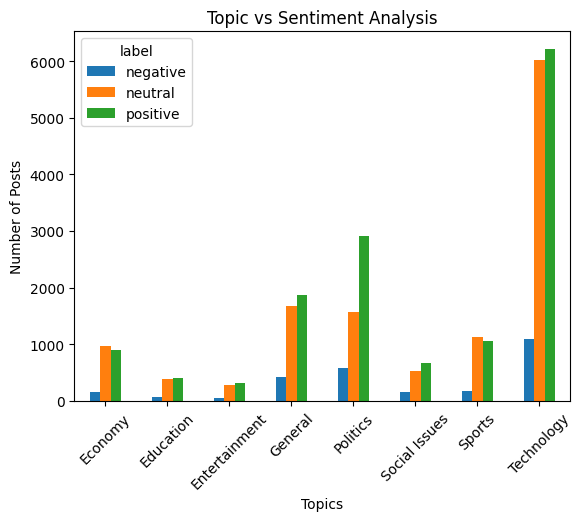

In [12]:
#Topic vs Sentiment Anlysis
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
topic_sentiment.plot(kind="bar")

plt.title("Topic vs Sentiment Analysis")
plt.xlabel("Topics")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)

plt.show()

<Figure size 1600x1800 with 0 Axes>

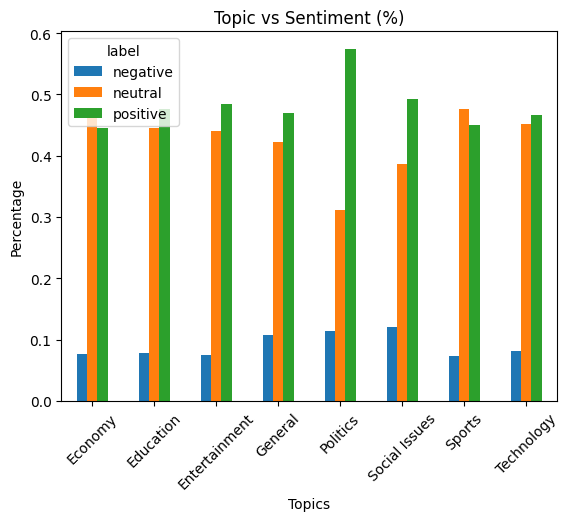

In [13]:
#Percentage Graph
topic_sentiment_percent = topic_sentiment.div(topic_sentiment.sum(axis=1), axis=0)

plt.figure(figsize=(16,18))
topic_sentiment_percent.plot(kind="bar")

plt.title("Topic vs Sentiment (%)")
plt.xlabel("Topics")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.show()

In [14]:
#Most Positive Topics
top_positive = topic_sentiment_percent["positive"].sort_values(ascending=False)
print(top_positive)

topic
Politics         0.574056
Social Issues    0.492937
Entertainment    0.484472
Education        0.476636
General          0.469033
Technology       0.466446
Sports           0.450764
Economy          0.445825
Name: positive, dtype: float64


In [15]:
#Most Negative topics
top_negative = topic_sentiment_percent["negative"].sort_values(ascending=False)
print(top_negative)


topic
Social Issues    0.120446
Politics         0.114693
General          0.108006
Technology       0.081895
Education        0.078271
Economy          0.076541
Entertainment    0.074534
Sports           0.073005
Name: negative, dtype: float64


In [16]:
#Most Discussed Topics
total_posts = topic_sentiment.sum(axis=1).sort_values(ascending=False)
print(total_posts)

topic
Technology       13322
Politics          5057
General           3972
Sports            2356
Economy           2012
Social Issues     1345
Education          856
Entertainment      644
dtype: int64


In [17]:
#Removing Other
df = df[df["topic"] != "Other"]

In [18]:
#Day 4
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [19]:
#Creating strong Custom Stowords
custom_stopwords = [
    "people","dont","like","just","know","think",
    "india","indian","indians","thats","hai","right",
    "need","better","good","make","want","time",
    "said","say","really","thing","things","im","ive",
    "got","get","still","also","even","one","many",
    "much","well","going","way","back"
]

custom_stopwords += [
    "bhai","life","years","year","happen","happened",
    "country","countries","world","live","north","south",
    "multiple","following","thread","showing"
]
custom_stopwords += [
    "happy","work","money","doesnt","does","you're",
    "parents","queries","growing","factor","watch",
    "film","shit"
]
custom_stopwords += [
    "you're","didnt","person","family","case","happens",
    "doing","shown","showed","point","come","leave",
    "knowing","didn","doesn","youre"
]

In [20]:
#Creating Topic Wise Keywords
from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_keywords_tfidf(text_series, n=8):
    vectorizer = TfidfVectorizer(
        max_features=1000,
        stop_words='english'
    )
    
    X = vectorizer.fit_transform(text_series)
    feature_names = vectorizer.get_feature_names_out()
    
    scores = X.sum(axis=0).A1
    sorted_indices = scores.argsort()[::-1]   #no slicing here
    
    keywords = []
    
    for i in sorted_indices:
        word = feature_names[i]
        
        if word not in custom_stopwords and len(word) > 3:
            keywords.append(word)
        
        if len(keywords) == n:
            break
    
    return keywords

In [21]:
#Showing keywords for each topic
topic_keywords = {}

for topic in df["topic"].unique():
    topic_text = df[df["topic"] == topic]["clean_text"]
    topic_keywords[topic] = get_top_keywords_tfidf(topic_text)

topic_keywords

{'Technology': ['women',
  'data',
  'feel',
  'help',
  'wait',
  'getting',
  'internet',
  'used'],
 'General': ['china',
  'population',
  'culture',
  'canada',
  'problem',
  'mean',
  'indias',
  'post'],
 'Sports': ['team',
  'cricket',
  'wing',
  'winning',
  'match',
  'times',
  'women',
  'support'],
 'Politics': ['government',
  'modi',
  'congress',
  'election',
  'elections',
  'party',
  'vote',
  'state'],
 'Economy': ['jobs',
  'market',
  'price',
  'economy',
  'prices',
  'inflation',
  'high',
  'getting'],
 'Social Issues': ['women',
  'police',
  'crime',
  'laws',
  'rights',
  'lawyer',
  'crimes',
  'rape'],
 'Entertainment': ['movie',
  'movies',
  'shows',
  'music',
  'actors',
  'story',
  'films',
  'real'],
 'Education': ['school',
  'college',
  'students',
  'study',
  'example',
  'student',
  'schools',
  'colleges']}

In [22]:
# =========================
# FINAL CLEAN HASHTAGS (ULTIMATE FIX)
# =========================

bad_words = [
    "time","life","thing","make","good","really","problem","example","study",
    "people","just","like","dont","know","feel","help","wait",
    "mean","point","getting","used","case","person","family","said",
    "does","didnt","youre","also","even","still","much","many",
    "women","team","match","wing","data"
]

replace_map = {
    "internet": "Tech",
    "jobs": "Jobs",
    "economy": "Economy",
    "market": "Market",
    "movie": "MovieBuzz",
    "movies": "MoviesBuzz",
    "music": "MusicBuzz",
    "school": "SchoolLife",
    "college": "CollegeLife",
    "students": "StudentLife",
    "cricket": "Cricket",
    "government": "Government",
    "election": "Election",
    "price": "Inflation"
}

topic_hashtags = {}

for topic, words in topic_keywords.items():
    hashtags = []

    for w in words:
        w = w.lower()

        if w in bad_words:
            continue

        if len(w) < 4:
            continue

        w = replace_map.get(w, w)

        tag = "#" + w.capitalize()

        if tag not in hashtags:
            hashtags.append(tag)

    # ensure minimum hashtags
    if len(hashtags) < 3:
        hashtags += ["#Trending", "#India", "#News"]

    topic_hashtags[topic] = hashtags[:5]


# India context fix (no duplication)
for topic in ["Politics", "Economy", "General"]:
    clean_tags = []

    for tag in topic_hashtags[topic]:
        word = tag.replace("#", "")

        if not word.lower().startswith("india"):
            word = "India" + word

        clean_tags.append("#" + word)

    topic_hashtags[topic] = clean_tags


# Final table
final_df = pd.DataFrame({
    "Topic": topic_hashtags.keys(),
    "Suggested Hashtags": [
        ", ".join(topic_hashtags[t]) for t in topic_hashtags
    ]
})

final_df

,Topic,Suggested Hashtags
0,Technology,"#Tech, #Trending, #India, #News"
1,General,"#IndiaChina, #IndiaPopulation, #IndiaCulture, ..."
2,Sports,"#Cricket, #Winning, #Times, #Support"
3,Politics,"#IndiaGovernment, #IndiaModi, #IndiaCongress, ..."
4,Economy,"#IndiaJobs, #IndiaMarket, #IndiaInflation, #In..."
5,Social Issues,"#Police, #Crime, #Laws, #Rights, #Lawyer"
6,Entertainment,"#Moviebuzz, #Moviesbuzz, #Shows, #Musicbuzz, #..."
7,Education,"#Schoollife, #Collegelife, #Studentlife, #Stud..."
